In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load the iris dataset from sklearn
iris = load_iris()

# Convert it into a clean Pandas Dataframe so it looks like a spreadsheet
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map target numbers (0, 1, 2) to actual flower names
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# View the first 5 rows of your data
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


C:\Users\shrey\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


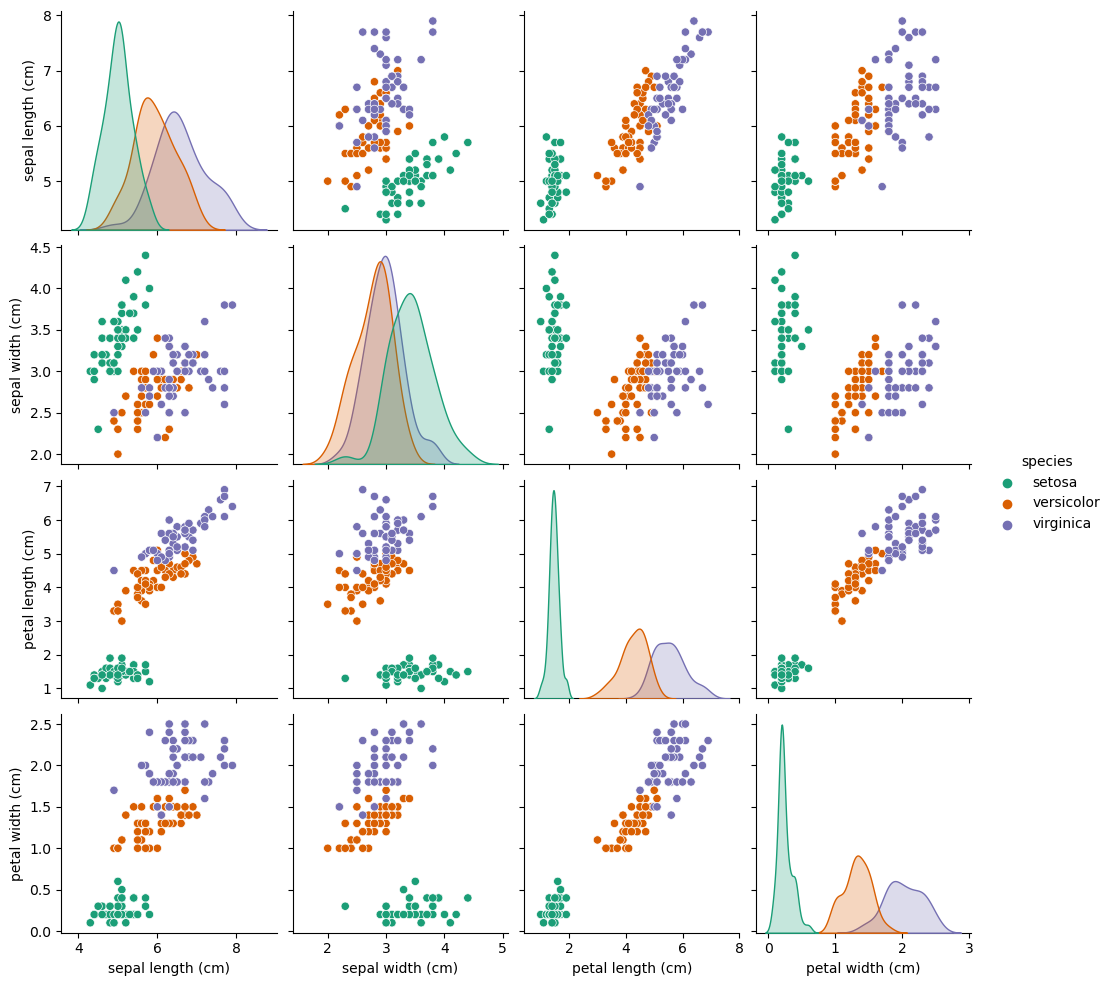

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pairplot to see how features separate by species
sns.pairplot(df, hue='species', palette='Dark2')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Define X (features/measurements) and y (target/species name)
X = df.drop('species', axis=1)
y = df['species']

# FIX: Change 'test_split' to 'test_size'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the two required models
model_lr = LogisticRegression(max_iter=200)
model_rf = RandomForestClassifier()

# Train both models
model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)


RandomForestClassifier()

In [5]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict using Logistic Regression
pred_lr = model_lr.predict(X_test)
print("--- Logistic Regression Report ---")
print(classification_report(y_test, pred_lr))

# Predict using Random Forest
pred_rf = model_rf.predict(X_test)
print("\n--- Random Forest Report ---")
print(classification_report(y_test, pred_rf))

--- Logistic Regression Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


--- Random Forest Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

